# Descriptive Analysis

## General Conclusions
- xx

In [1]:
import sys
sys.path.insert(0, "../..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import yaml

# --- Setup ---
with open("../../config.yml", "r") as f:
    config = yaml.safe_load(f)

# --- Load indicators panel ---
panel = pd.read_parquet("../../data/processed_data/analysis_panel.parquet")


print(f"Shape: {panel.shape}")
print(f"Sectors: {sorted(panel['IS8_SECTOR'].unique())}")
print(f"Years: {panel['YEAR'].min()} — {panel['YEAR'].max()}")
print(f"LADs: {panel['GEOGRAPHY_CODE'].nunique()}")

Shape: (17150, 57)
Sectors: ['Advanced Manufacturing', 'Creative Industries', 'Defence', 'Digital and Technologies', 'Financial Services', 'Life Sciences', 'Professional and Business Services']
Years: 2016 — 2022
LADs: 350


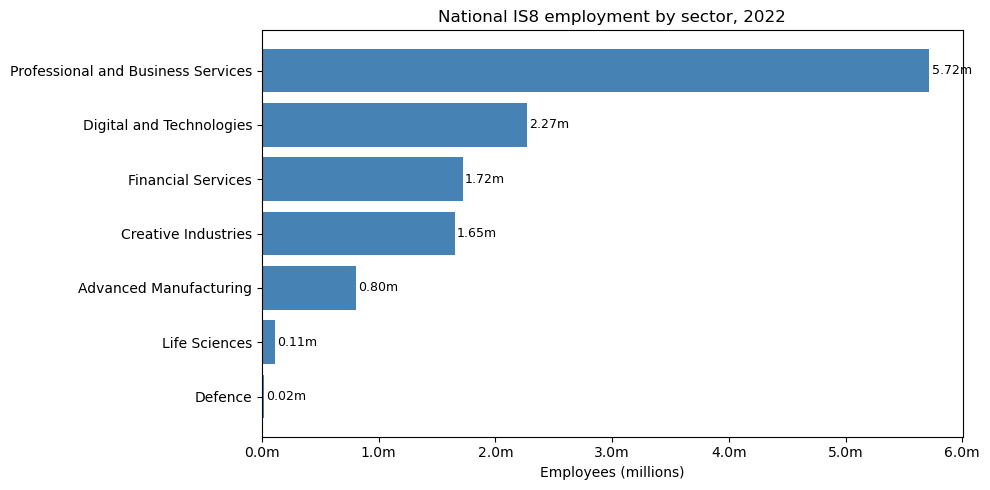

In [2]:
# --- National IS8 employment by sector (most recent year) ---
latest_year = panel['YEAR'].max()
national = (
    panel[panel['YEAR'] == latest_year]
    .groupby('IS8_SECTOR')['EMPLOYEES']
    .sum()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(national.index, national.values / 1_000_000, color='steelblue')
ax.set_xlabel('Employees (millions)')
ax.set_title(f'National IS8 employment by sector, {latest_year}')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}m'))
for bar, val in zip(bars, national.values):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'{val/1_000_000:.2f}m', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../../output/graphs/Franco/national_is8_employment_2022.png', dpi=150)
plt.show()

In [3]:
print(panel[panel['IS8_SECTOR'] == 'Defence']['EMPLOYEES'].describe())
print(f"\nDefence total 2022: {panel[(panel['IS8_SECTOR']=='Defence') & (panel['YEAR']==2022)]['EMPLOYEES'].sum():,}")
print(f"Non-zero LADs 2022: {(panel[(panel['IS8_SECTOR']=='Defence') & (panel['YEAR']==2022)]['EMPLOYEES'] > 0).sum()}")

count    2450.000000
mean       48.279591
std       359.879089
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max      6000.000000
Name: EMPLOYEES, dtype: float64

Defence total 2022: 17,670.0
Non-zero LADs 2022: 61


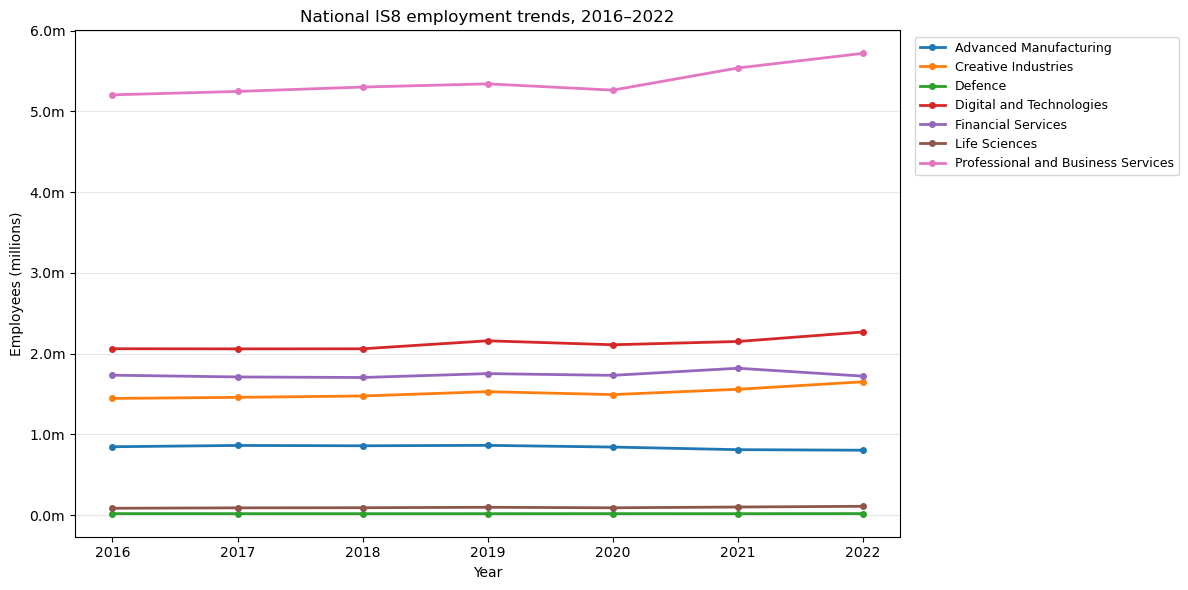

In [4]:
# --- National IS8 employment trends 2016–2022 ---
trends = (
    panel
    .groupby(['YEAR', 'IS8_SECTOR'])['EMPLOYEES']
    .sum()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))

sectors = sorted(trends['IS8_SECTOR'].unique())
colors = plt.cm.tab10.colors

for i, sector in enumerate(sectors):
    data = trends[trends['IS8_SECTOR'] == sector].sort_values('YEAR')
    ax.plot(data['YEAR'], data['EMPLOYEES'] / 1_000_000,
            label=sector, color=colors[i], linewidth=2, marker='o', markersize=4)

ax.set_xlabel('Year')
ax.set_ylabel('Employees (millions)')
ax.set_title('National IS8 employment trends, 2016–2022')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}m'))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../../output/graphs/Franco/national_is8_trends_2016_2022.png', dpi=150, bbox_inches='tight')
plt.show()

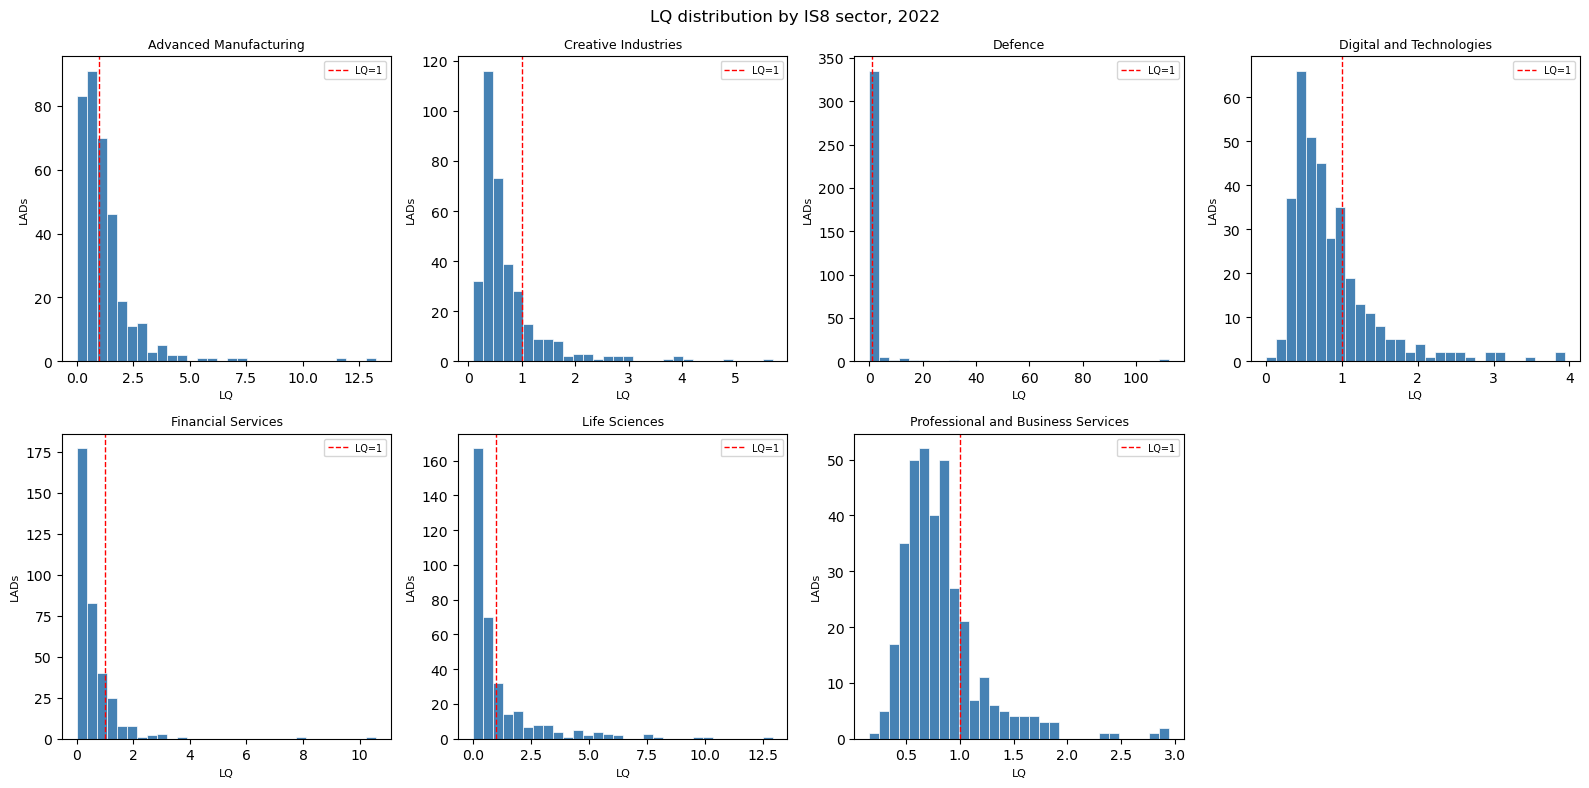

In [5]:
# --- LQ distribution by IS8 sector (most recent year) ---
lq_latest = panel[panel['YEAR'] == latest_year][['GEOGRAPHY_NAME', 'IS8_SECTOR', 'lq_emp']].dropna()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

sectors = sorted(lq_latest['IS8_SECTOR'].unique())

for i, sector in enumerate(sectors):
    data = lq_latest[lq_latest['IS8_SECTOR'] == sector]['lq_emp']
    axes[i].hist(data, bins=30, color='steelblue', edgecolor='white', linewidth=0.5)
    axes[i].axvline(x=1, color='red', linestyle='--', linewidth=1, label='LQ=1')
    axes[i].set_title(sector, fontsize=9)
    axes[i].set_xlabel('LQ', fontsize=8)
    axes[i].set_ylabel('LADs', fontsize=8)
    axes[i].legend(fontsize=7)

# hide the 8th subplot (only 7 sectors)
axes[7].set_visible(False)

plt.suptitle(f'LQ distribution by IS8 sector, {latest_year}', fontsize=12)
plt.tight_layout()
plt.savefig(f'../../output/graphs/Franco/lq_distribution_{latest_year}.png', dpi=150, bbox_inches='tight')
plt.show()

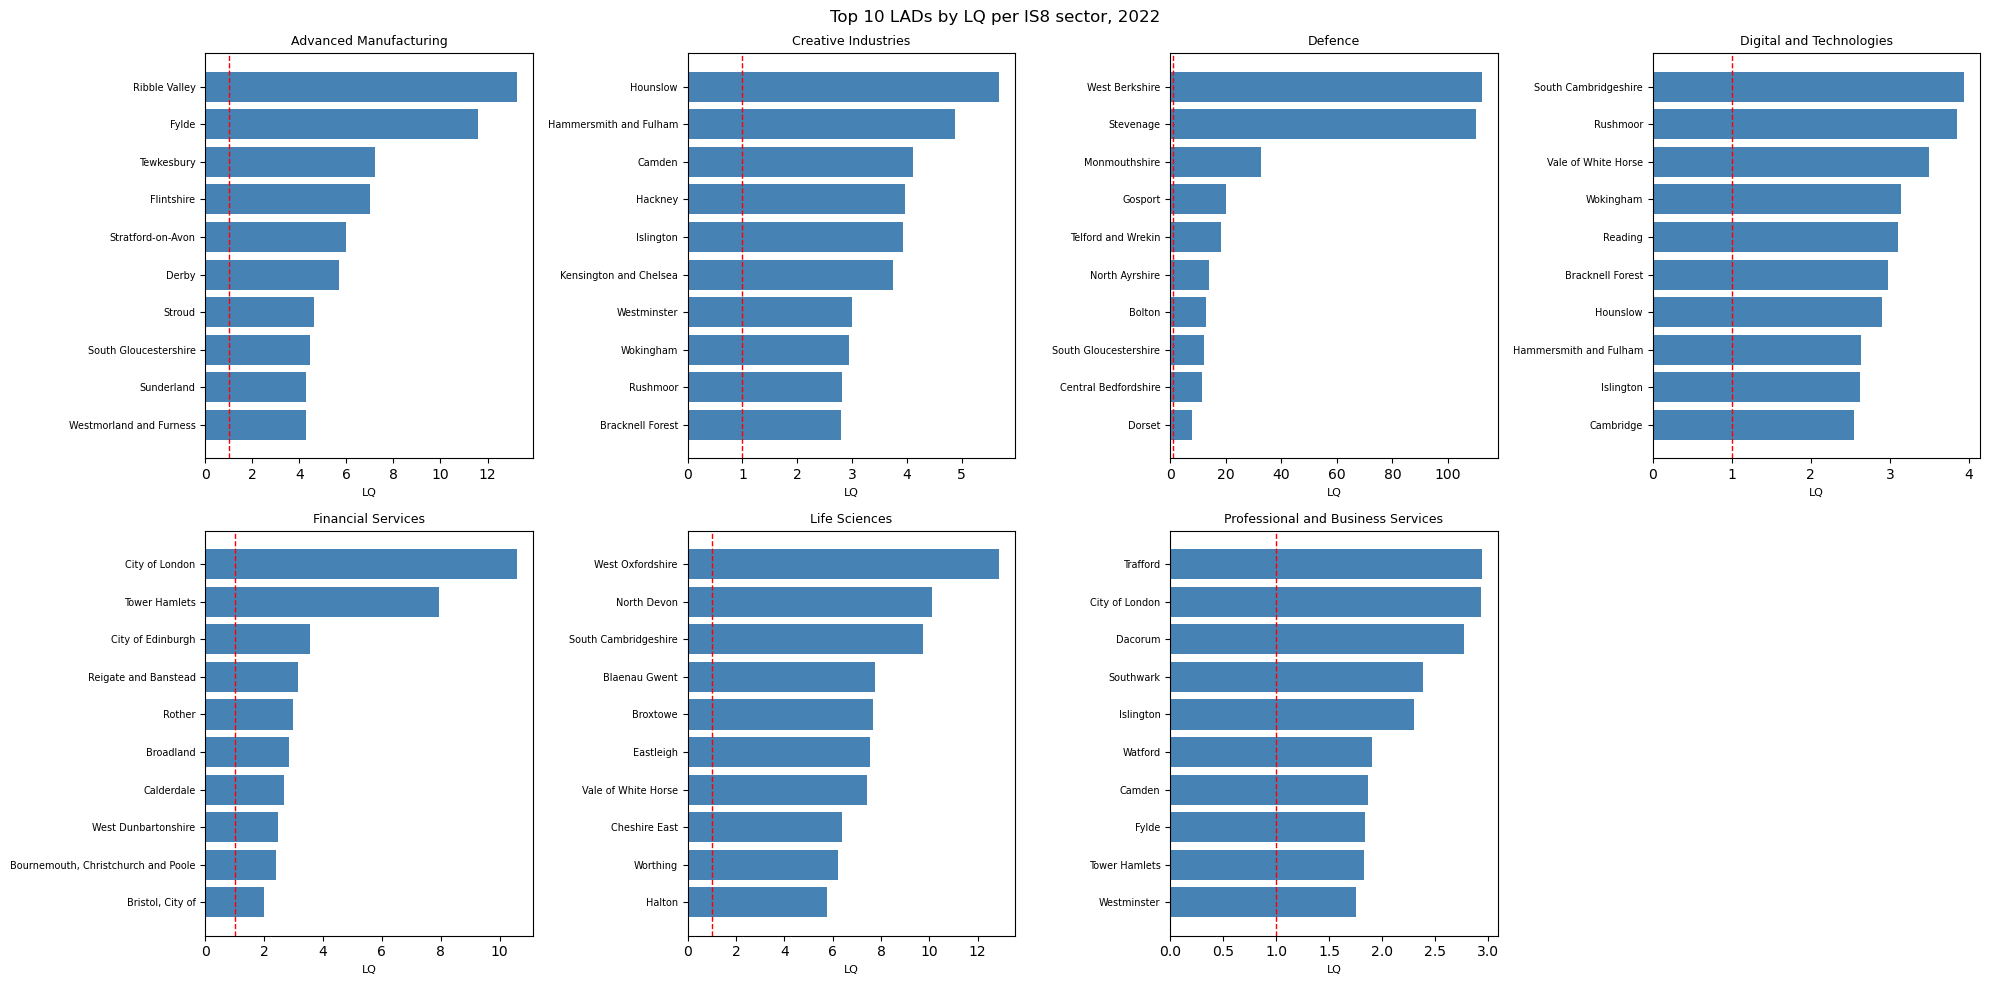

In [6]:
# --- Top 10 LADs by LQ for each IS8 sector (most recent year) ---
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, sector in enumerate(sectors):
    data = (
        lq_latest[lq_latest['IS8_SECTOR'] == sector]
        .nlargest(10, 'lq_emp')
        .sort_values('lq_emp', ascending=True)
    )
    axes[i].barh(data['GEOGRAPHY_NAME'], data['lq_emp'], color='steelblue')
    axes[i].axvline(x=1, color='red', linestyle='--', linewidth=1)
    axes[i].set_title(sector, fontsize=9)
    axes[i].set_xlabel('LQ', fontsize=8)
    axes[i].tick_params(axis='y', labelsize=7)

axes[7].set_visible(False)

plt.suptitle(f'Top 10 LADs by LQ per IS8 sector, {latest_year}', fontsize=12)
plt.tight_layout()
plt.savefig(f'../../output/graphs/Franco/top10_lq_by_sector_{latest_year}.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
from src.regions import RegionMapper

mapper = RegionMapper(config, panel)
mapper.verify()

South Yorkshire MCA (4 LADs): ['Barnsley', 'Doncaster', 'Rotherham', 'Sheffield']
West Midlands CA (7 LADs): ['Birmingham', 'Coventry', 'Dudley', 'Sandwell', 'Solihull', 'Walsall', 'Wolverhampton']
West Yorkshire CA (5 LADs): ['Bradford', 'Calderdale', 'Kirklees', 'Leeds', 'Wakefield']
Greater Manchester CA (10 LADs): ['Bolton', 'Bury', 'Manchester', 'Oldham', 'Rochdale', 'Salford', 'Stockport', 'Tameside', 'Trafford', 'Wigan']
West of England CA (3 LADs): ['Bath and North East Somerset', 'Bristol, City of', 'South Gloucestershire']
Liverpool City Region (6 LADs): ['Halton', 'Knowsley', 'Liverpool', 'St. Helens', 'Sefton', 'Wirral']
London (33 LADs): ['City of London', 'Barking and Dagenham', 'Barnet', 'Bexley', 'Brent', 'Bromley', 'Camden', 'Croydon', 'Ealing', 'Enfield', 'Greenwich', 'Hackney', 'Hammersmith and Fulham', 'Haringey', 'Harrow', 'Havering', 'Hillingdon', 'Hounslow', 'Islington', 'Kensington and Chelsea', 'Kingston upon Thames', 'Lambeth', 'Lewisham', 'Merton', 'Newham', 

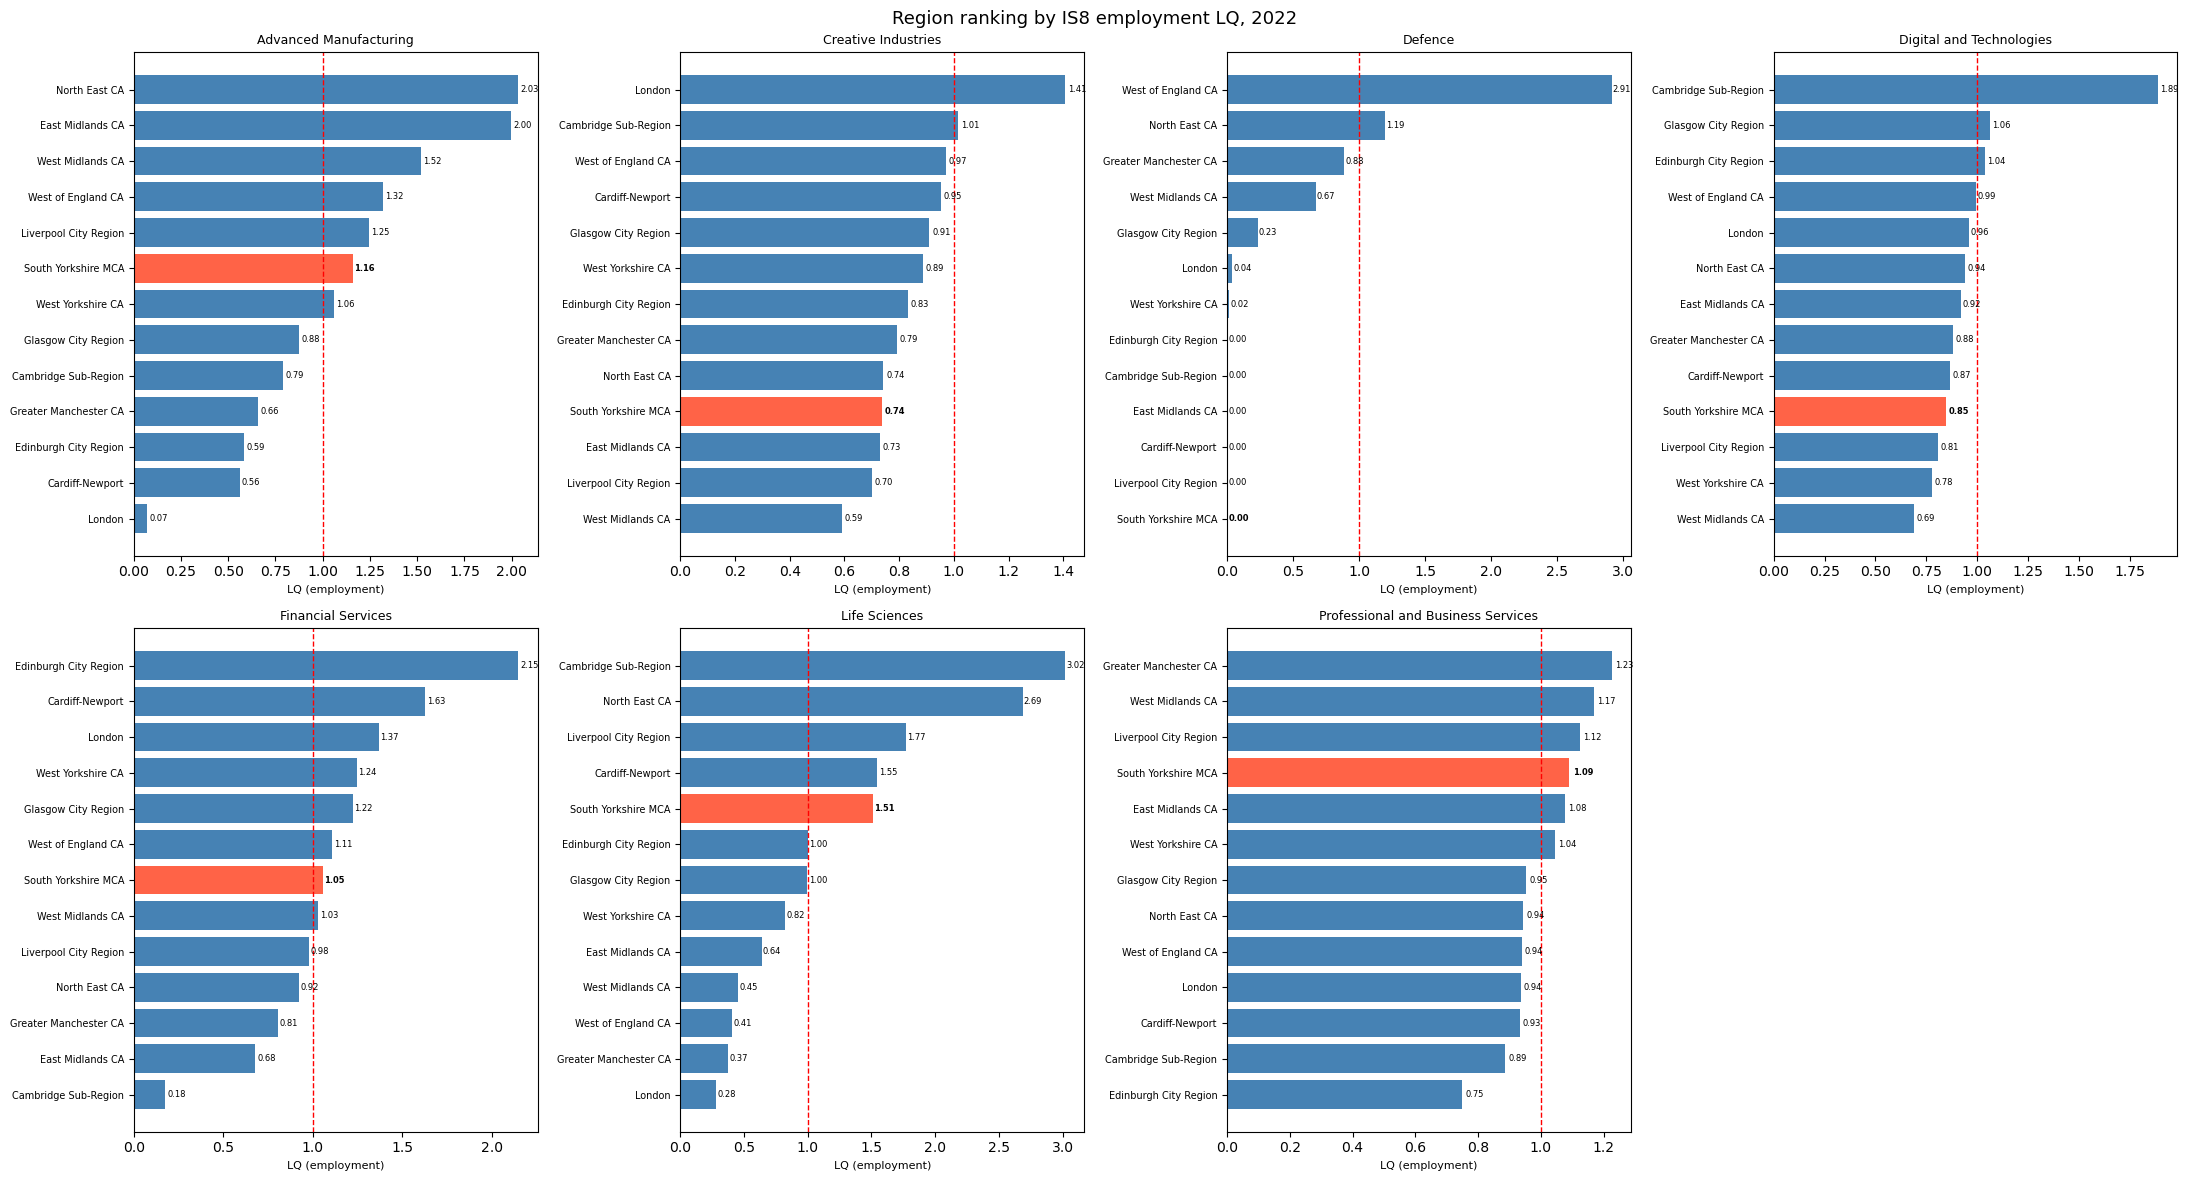

In [10]:
# --- Region ranking by LQ per IS8 sector (most recent year, region-level aggregation) ---
region_map = mapper.get()

latest = panel[panel['YEAR'] == latest_year][['GEOGRAPHY_CODE', 'IS8_SECTOR', 'EMPLOYEES']].dropna()

# national totals
nat_total = latest['EMPLOYEES'].sum()
nat_by_sector = latest.groupby('IS8_SECTOR')['EMPLOYEES'].sum()

# region-level LQ
rows = []
for region, codes in region_map.items():
    region_data = latest[latest['GEOGRAPHY_CODE'].isin(codes)]
    region_total = region_data['EMPLOYEES'].sum()
    region_by_sector = region_data.groupby('IS8_SECTOR')['EMPLOYEES'].sum()
    lq = (region_by_sector / region_total) / (nat_by_sector / nat_total)
    lq = lq.reset_index()
    lq.columns = ['IS8_SECTOR', 'lq_emp']
    lq['region'] = region
    rows.append(lq)

region_lq = pd.concat(rows, ignore_index=True)

# plot
sectors = sorted(region_lq['IS8_SECTOR'].unique())
fig, axes = plt.subplots(2, 4, figsize=(22, 12))
axes = axes.flatten()

HIGHLIGHT = 'South Yorkshire MCA'

for i, sector in enumerate(sectors):
    data = (
        region_lq[region_lq['IS8_SECTOR'] == sector]
        .sort_values('lq_emp', ascending=True)
    )
    ax = axes[i]
    colors = ['tomato' if r == HIGHLIGHT else 'steelblue' for r in data['region']]
    bars = ax.barh(data['region'], data['lq_emp'], color=colors)
    ax.axvline(x=1, color='red', linestyle='--', linewidth=1)
    ax.set_title(sector, fontsize=9)
    ax.set_xlabel('LQ (employment)', fontsize=8)
    ax.tick_params(axis='y', labelsize=7)
    for bar, val, region in zip(bars, data['lq_emp'], data['region']):
        weight = 'bold' if region == HIGHLIGHT else 'normal'
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}', va='center', fontsize=6, fontweight=weight)

axes[7].set_visible(False)

plt.suptitle(f'Region ranking by IS8 employment LQ, {latest_year}', fontsize=13)
plt.tight_layout()
plt.savefig(f'../../output/graphs/Franco/region_ranking_lq_{latest_year}.png', dpi=150, bbox_inches='tight')
plt.show()

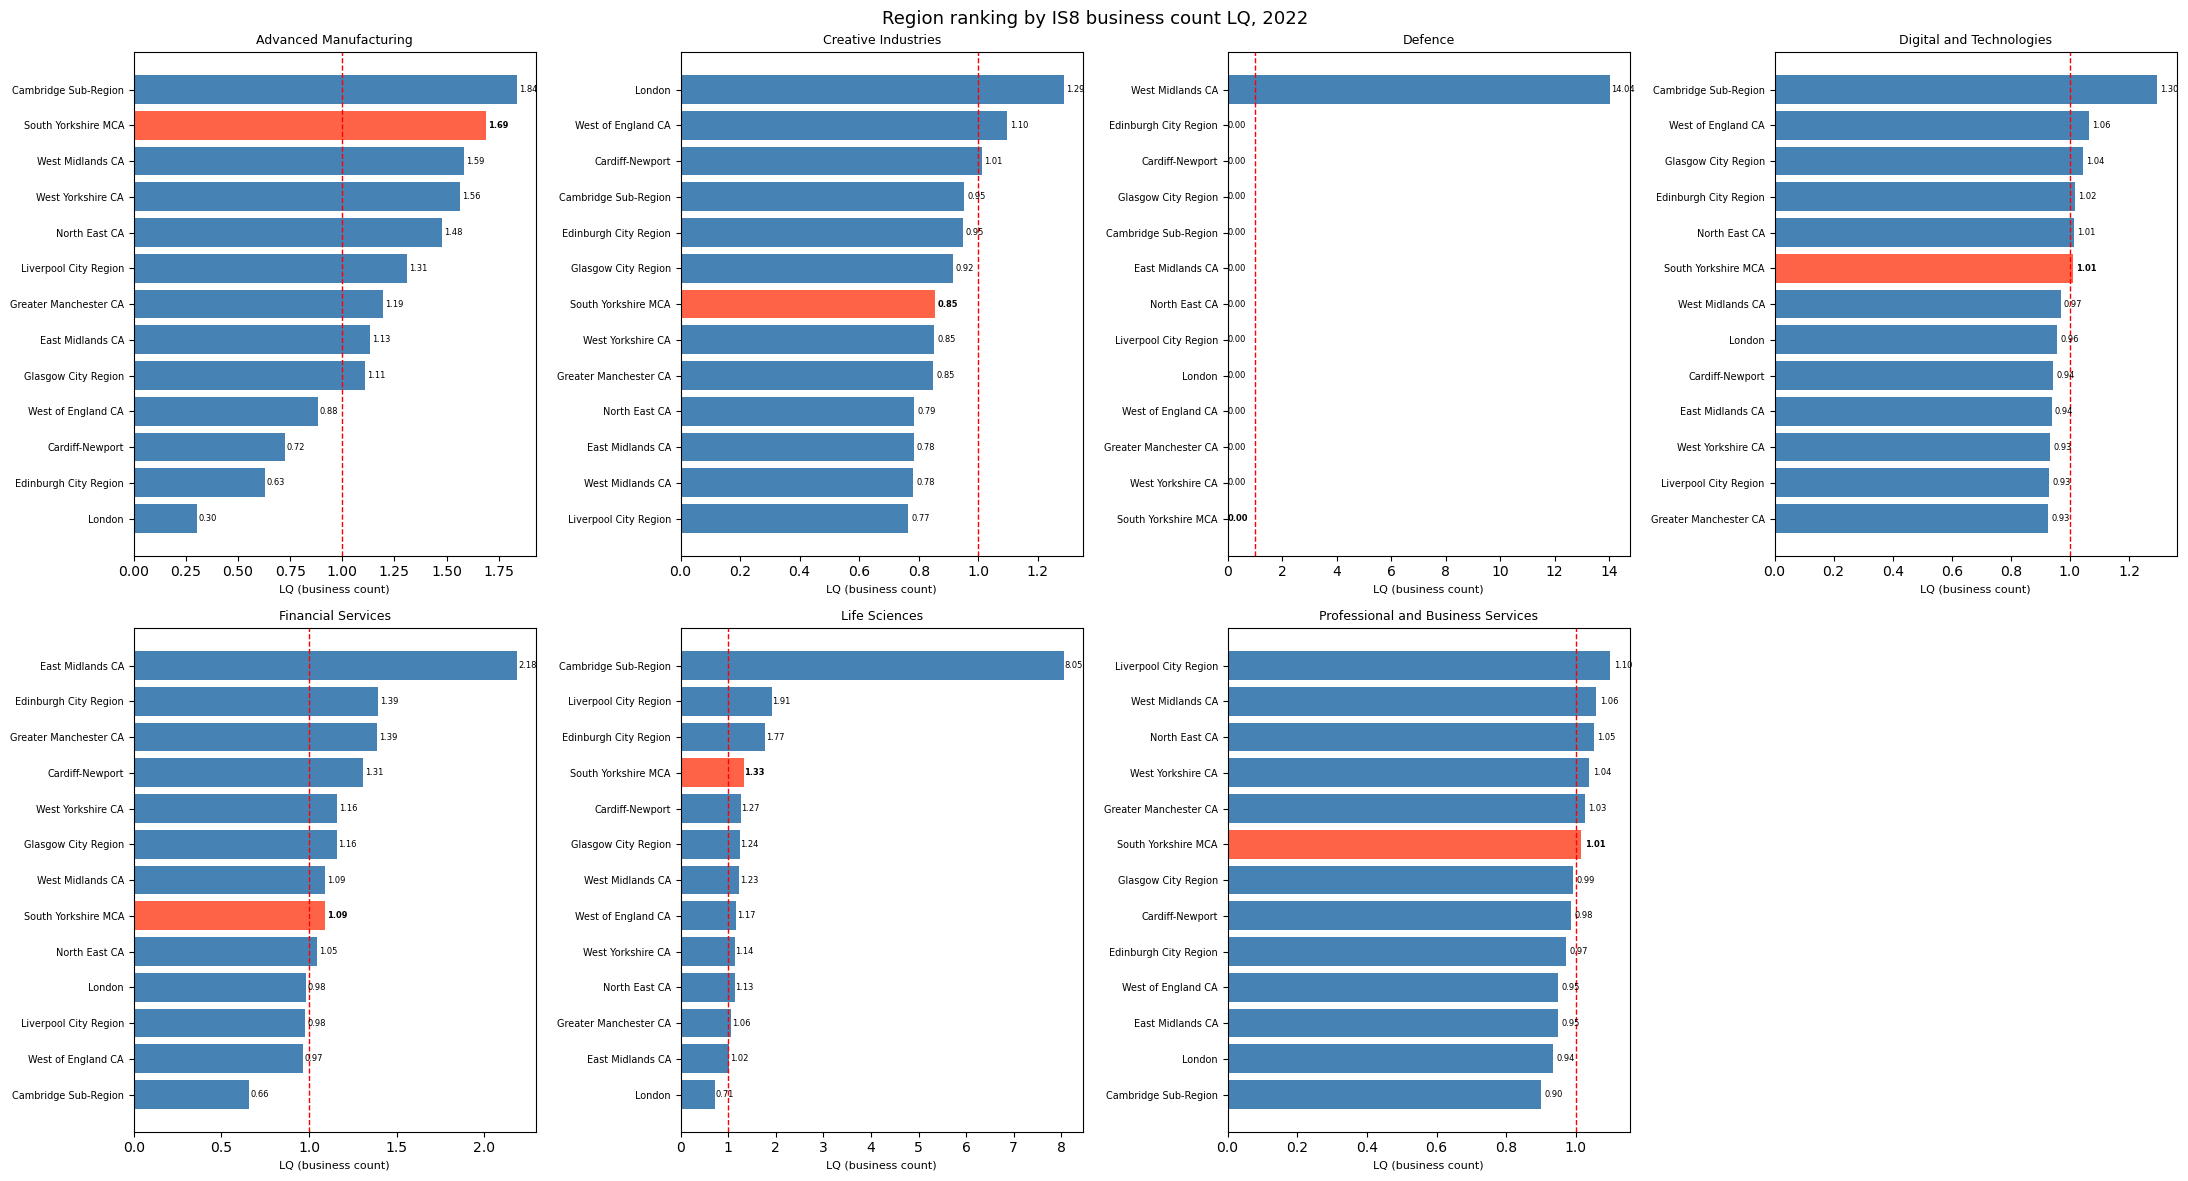

In [11]:
# --- Region ranking by LQ per IS8 sector — business count (most recent year) ---
latest_bus = panel[panel['YEAR'] == latest_year][['GEOGRAPHY_CODE', 'IS8_SECTOR', 'BUSINESSES']].dropna()

# national totals
nat_total_bus = latest_bus['BUSINESSES'].sum()
nat_by_sector_bus = latest_bus.groupby('IS8_SECTOR')['BUSINESSES'].sum()

# region-level LQ
rows = []
for region, codes in region_map.items():
    region_data = latest_bus[latest_bus['GEOGRAPHY_CODE'].isin(codes)]
    region_total = region_data['BUSINESSES'].sum()
    region_by_sector = region_data.groupby('IS8_SECTOR')['BUSINESSES'].sum()
    lq = (region_by_sector / region_total) / (nat_by_sector_bus / nat_total_bus)
    lq = lq.reset_index()
    lq.columns = ['IS8_SECTOR', 'lq_bus']
    lq['region'] = region
    rows.append(lq)

region_lq_bus = pd.concat(rows, ignore_index=True)

# plot
sectors = sorted(region_lq_bus['IS8_SECTOR'].unique())
fig, axes = plt.subplots(2, 4, figsize=(22, 12))
axes = axes.flatten()

HIGHLIGHT = 'South Yorkshire MCA'

for i, sector in enumerate(sectors):
    data = (
        region_lq_bus[region_lq_bus['IS8_SECTOR'] == sector]
        .sort_values('lq_bus', ascending=True)
    )
    ax = axes[i]
    colors = ['tomato' if r == HIGHLIGHT else 'steelblue' for r in data['region']]
    bars = ax.barh(data['region'], data['lq_bus'], color=colors)
    ax.axvline(x=1, color='red', linestyle='--', linewidth=1)
    ax.set_title(sector, fontsize=9)
    ax.set_xlabel('LQ (business count)', fontsize=8)
    ax.tick_params(axis='y', labelsize=7)
    for bar, val, region in zip(bars, data['lq_bus'], data['region']):
        weight = 'bold' if region == HIGHLIGHT else 'normal'
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}', va='center', fontsize=6, fontweight=weight)

axes[7].set_visible(False)

plt.suptitle(f'Region ranking by IS8 business count LQ, {latest_year}', fontsize=13)
plt.tight_layout()
plt.savefig(f'../../output/graphs/Franco/region_ranking_lq_bus_{latest_year}.png', dpi=150, bbox_inches='tight')
plt.show()

Growth computed from 2016 to 2022


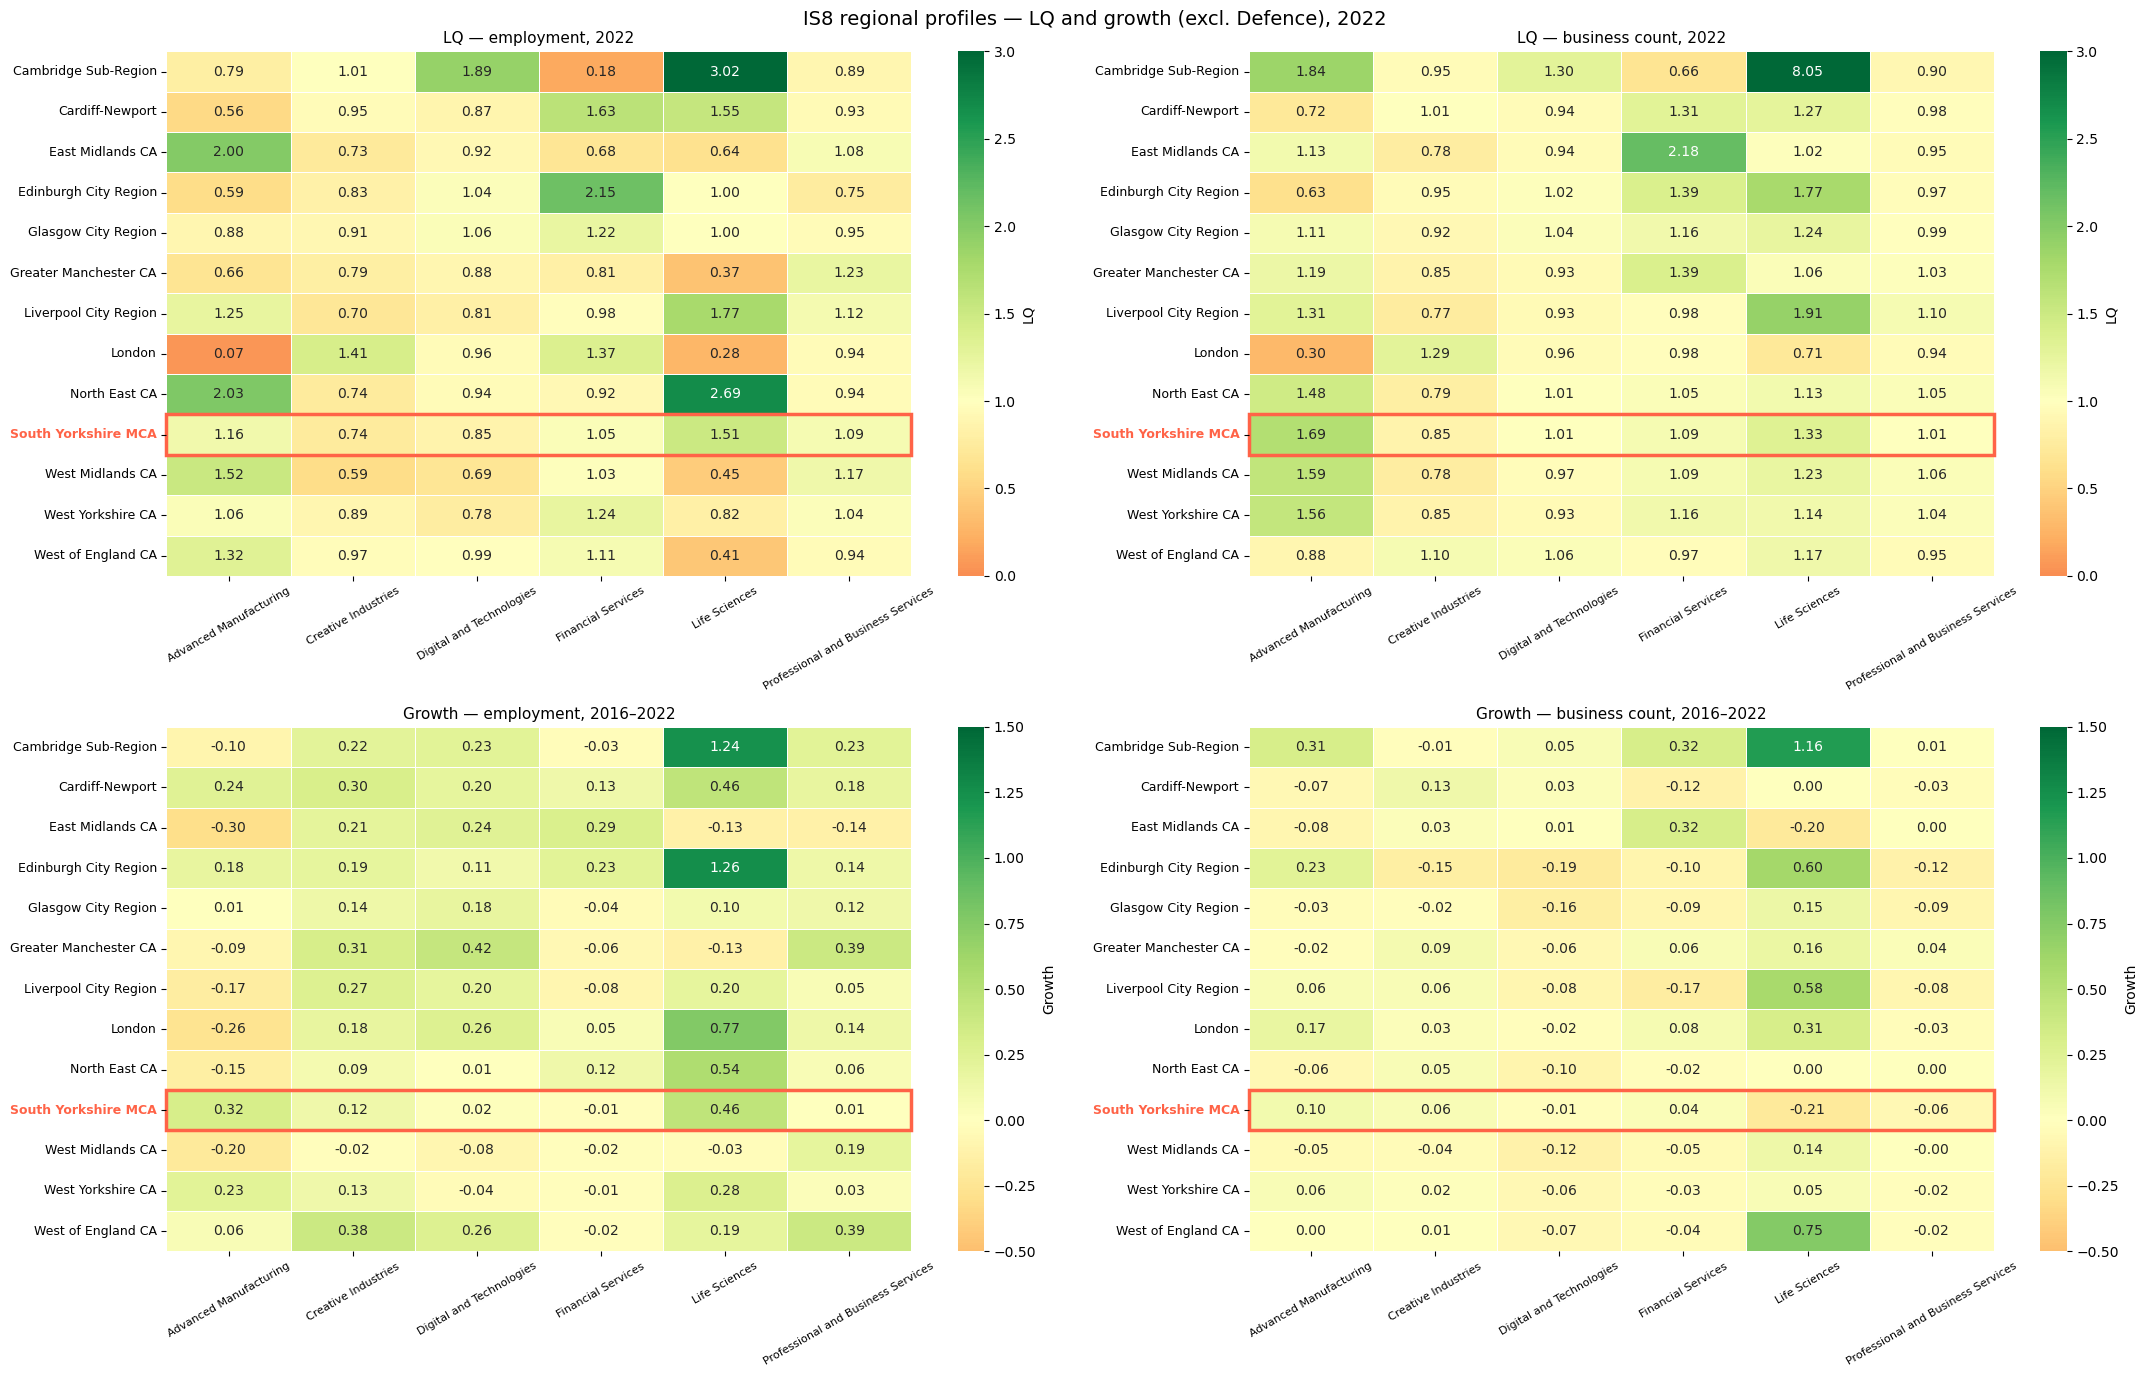

In [15]:
# --- 4-panel heatmap: LQ and growth by region (all region-level aggregation, excl. Defence) ---
import seaborn as sns
import matplotlib.patches as patches

HIGHLIGHT = 'South Yorkshire MCA'

end_year = panel['YEAR'].max()

available_years = sorted(panel.dropna(subset=['EMPLOYEES', 'BUSINESSES'])['YEAR'].unique())
start_year = available_years[0]

print(f"Growth computed from {start_year} to {end_year}")

emp_start = panel[panel['YEAR'] == start_year][['GEOGRAPHY_CODE', 'IS8_SECTOR', 'EMPLOYEES']]
emp_end   = panel[panel['YEAR'] == end_year][['GEOGRAPHY_CODE', 'IS8_SECTOR', 'EMPLOYEES']]
bus_start = panel[panel['YEAR'] == start_year][['GEOGRAPHY_CODE', 'IS8_SECTOR', 'BUSINESSES']].dropna()
bus_end   = panel[panel['YEAR'] == end_year][['GEOGRAPHY_CODE', 'IS8_SECTOR', 'BUSINESSES']].dropna()

def region_level_growth(start_df, end_df, value_col):
    rows = []
    for region, codes in region_map.items():
        s = start_df[start_df['GEOGRAPHY_CODE'].isin(codes)].groupby('IS8_SECTOR')[value_col].sum()
        e = end_df[end_df['GEOGRAPHY_CODE'].isin(codes)].groupby('IS8_SECTOR')[value_col].sum()
        growth = ((e - s) / s).reset_index()
        growth.columns = ['IS8_SECTOR', 'growth']
        growth['region'] = region
        rows.append(growth)
    df = pd.concat(rows, ignore_index=True)
    return df.pivot(index='region', columns='IS8_SECTOR', values='growth').round(2)

lq_emp_pivot     = region_lq.pivot(index='region', columns='IS8_SECTOR', values='lq_emp').round(2)
lq_bus_pivot     = region_lq_bus.pivot(index='region', columns='IS8_SECTOR', values='lq_bus').round(2)
growth_emp_pivot = region_level_growth(emp_start, emp_end, 'EMPLOYEES')
growth_bus_pivot = region_level_growth(bus_start, bus_end, 'BUSINESSES')

# drop Defence from all pivots
for pivot in [lq_emp_pivot, lq_bus_pivot, growth_emp_pivot, growth_bus_pivot]:
    if 'Defence' in pivot.columns:
        pivot.drop(columns='Defence', inplace=True)

heatmap_configs = [
    (lq_emp_pivot,     f'LQ — employment, {latest_year}',                    'RdYlGn', 1,  0,    3,   'LQ'),
    (lq_bus_pivot,     f'LQ — business count, {latest_year}',                'RdYlGn', 1,  0,    3,   'LQ'),
    (growth_emp_pivot, f'Growth — employment, {start_year}–{end_year}',      'RdYlGn', 0, -0.5,  1.5, 'Growth'),
    (growth_bus_pivot, f'Growth — business count, {start_year}–{end_year}',  'RdYlGn', 0, -0.5,  1.5, 'Growth'),
]

fig, axes = plt.subplots(2, 2, figsize=(22, 14))

for ax, (pivot, title, cmap, center, vmin, vmax, cbar_label) in zip(axes.flatten(), heatmap_configs):
    data = pivot.astype(float).replace([np.inf, -np.inf], np.nan)
    sns.heatmap(
        data,
        annot=True, fmt='.2f', cmap=cmap, center=center,
        linewidths=0.5, linecolor='white',
        ax=ax, cbar_kws={'label': cbar_label},
        vmin=vmin, vmax=vmax
    )
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.tick_params(axis='y', rotation=0, labelsize=9)

    # highlight South Yorkshire row
    row_idx = list(pivot.index).index(HIGHLIGHT)
    n_cols = len(pivot.columns)
    ax.add_patch(patches.Rectangle(
        (0, row_idx), n_cols, 1,
        fill=False, edgecolor='tomato', lw=2.5, clip_on=False
    ))
    for tick in ax.get_yticklabels():
        if tick.get_text() == HIGHLIGHT:
            tick.set_color('tomato')
            tick.set_fontweight('bold')

plt.suptitle(f'IS8 regional profiles — LQ and growth (excl. Defence), {latest_year}', fontsize=14)
plt.tight_layout()
plt.savefig(f'../../output/graphs/Franco/regional_profiles_4panel_no_defence_{latest_year}.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
panel_ind = pd.read_parquet("../processed_data/indicators_panel.parquet")

print(f"lq_bus present: {'lq_bus' in panel_ind.columns}")
print(f"Non-null lq_bus: {panel_ind['lq_bus'].notna().sum():,}")
print(f"Null lq_bus: {panel_ind['lq_bus'].isna().sum():,}")
print(f"\nSample (Sheffield, Adv Mfg, 2023):")
print(panel_ind[
    (panel_ind['GEOGRAPHY_NAME'] == 'Sheffield') &
    (panel_ind['IS8_SECTOR'] == 'Advanced Manufacturing') &
    (panel_ind['YEAR'] == 2023)
][['lq_emp', 'lq_bus']].values)

In [ ]:
# --- Region-level LQ bus (from indicators panel) ---
lq_bus_2024 = panel_ind[panel_ind['YEAR'] == 2024][['GEOGRAPHY_CODE', 'IS8_SECTOR', 'lq_bus']].dropna()

region_lq_bus2 = []
for region, codes in region_map.items():
    region_data = lq_bus_2024[lq_bus_2024['GEOGRAPHY_CODE'].isin(codes)]
    avg_lq = region_data.groupby('IS8_SECTOR')['lq_bus'].mean().reset_index()
    avg_lq['region'] = region
    region_lq_bus2.append(avg_lq)

region_lq_bus2 = pd.concat(region_lq_bus2, ignore_index=True)
lq_bus_pivot2 = region_lq_bus2.pivot(index='region', columns='IS8_SECTOR', values='lq_bus').round(2)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(
    lq_bus_pivot2.astype(float),
    annot=True, fmt='.2f', cmap='RdYlGn', center=1,
    linewidths=0.5, linecolor='white',
    ax=ax, cbar_kws={'label': 'LQ (business count)'},
    vmin=0, vmax=5.5
)
ax.set_title('Region-level LQ — business count, 2024', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=30, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=9)
plt.tight_layout()
plt.savefig('../output/charts/regional_lq_bus_2024.png', dpi=150, bbox_inches='tight')
plt.show()

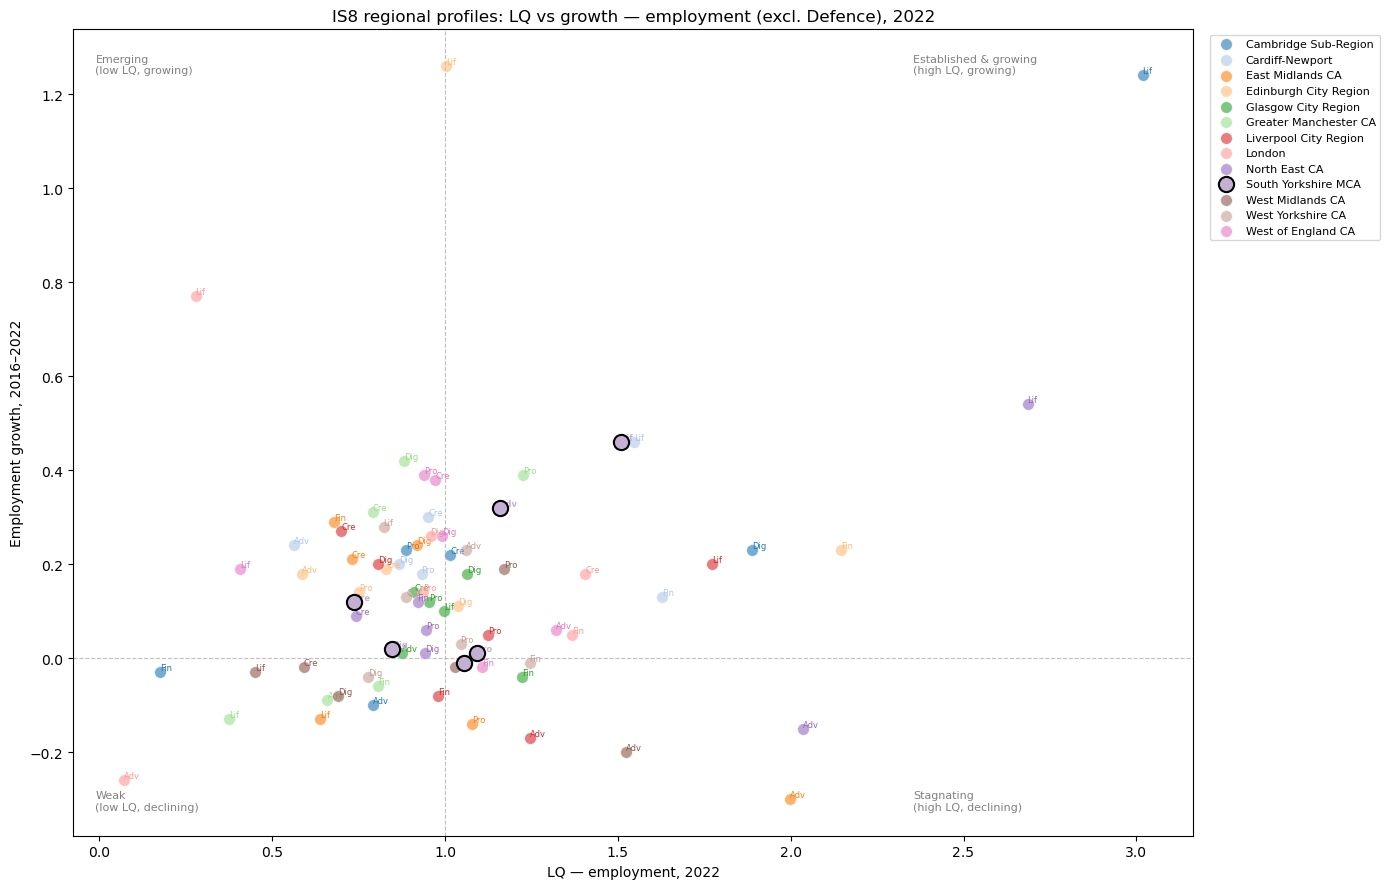

In [26]:
# --- 2D scatter: LQ vs growth by region and sector — employment (region-level aggregation) ---

# melt growth pivot back to long format
growth_long = growth_emp_pivot.reset_index().melt(id_vars='region', var_name='IS8_SECTOR', value_name='growth_emp')

# merge with region-level LQ
scatter_df = region_lq[['region', 'IS8_SECTOR', 'lq_emp']].merge(growth_long, on=['region', 'IS8_SECTOR'])

# exclude Defence
scatter_df = scatter_df[scatter_df['IS8_SECTOR'] != 'Defence']

HIGHLIGHT = 'South Yorkshire MCA'
regions = sorted(scatter_df['region'].unique())
colors = plt.cm.tab20.colors
region_colors = {r: colors[i] for i, r in enumerate(regions)}

fig, ax = plt.subplots(figsize=(14, 9))

for region in regions:
    data = scatter_df[scatter_df['region'] == region]
    is_highlight = region == HIGHLIGHT
    ax.scatter(data['lq_emp'], data['growth_emp'],
               color=region_colors[region],
               label=region,
               s=120 if is_highlight else 70,
               alpha=1.0 if is_highlight else 0.6,
               edgecolors='black' if is_highlight else 'white',
               linewidth=1.5 if is_highlight else 0.5,
               zorder=5 if is_highlight else 3)
    for _, row in data.iterrows():
        ax.annotate(row['IS8_SECTOR'][:3],
                    (row['lq_emp'], row['growth_emp']),
                    fontsize=6, ha='left', va='bottom',
                    color=region_colors[region],
                    fontweight='bold' if is_highlight else 'normal')

ax.axvline(x=1, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

ax.text(0.02, 0.97, 'Emerging\n(low LQ, growing)',               transform=ax.transAxes, fontsize=8, va='top',    color='gray')
ax.text(0.75, 0.97, 'Established & growing\n(high LQ, growing)', transform=ax.transAxes, fontsize=8, va='top',    color='gray')
ax.text(0.02, 0.03, 'Weak\n(low LQ, declining)',                 transform=ax.transAxes, fontsize=8, va='bottom', color='gray')
ax.text(0.75, 0.03, 'Stagnating\n(high LQ, declining)',          transform=ax.transAxes, fontsize=8, va='bottom', color='gray')

ax.set_xlabel(f'LQ — employment, {latest_year}', fontsize=10)
ax.set_ylabel(f'Employment growth, {start_year}–{end_year}', fontsize=10)
ax.set_title(f'IS8 regional profiles: LQ vs growth — employment (excl. Defence), {latest_year}', fontsize=12)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig(f'../../output/graphs/Franco/regional_scatter_lq_growth_emp_{latest_year}.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
from ipywidgets import SelectMultiple, Button, Output, VBox, HBox, Label
import ipywidgets as widgets
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

HIGHLIGHT = 'South Yorkshire MCA'
all_regions = sorted(scatter_df['region'].unique())
colors = plt.cm.tab20.colors
region_colors = {r: colors[i] for i, r in enumerate(all_regions)}

# --- widgets ---
region_selector = SelectMultiple(
    options=all_regions,
    value=all_regions,
    description='Regions:',
    layout={'width': '280px', 'height': '260px'}
)

select_all_btn   = Button(description='Select all',   button_style='', layout={'width': '120px'})
deselect_all_btn = Button(description='Deselect all', button_style='', layout={'width': '120px'})
out = Output()

def plot_scatter(selected_regions):
    out.clear_output(wait=True)
    with out:
        data = scatter_df[scatter_df['region'].isin(selected_regions)]
        fig, ax = plt.subplots(figsize=(14, 9))

        for region in selected_regions:
            rd = data[data['region'] == region]
            is_highlight = region == HIGHLIGHT
            for _, row in rd.iterrows():
                ax.annotate(row['IS8_SECTOR'][:3],
                            (row['lq_emp'], row['growth_emp']),
                            fontsize=6, ha='left', va='bottom',
                            color=region_colors[region],
                            fontweight='bold' if is_highlight else 'normal')

        ax.axvline(x=1, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
        ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

        ax.text(0.02, 0.97, 'Emerging\n(low LQ, growing)',               transform=ax.transAxes, fontsize=8, va='top',    color='gray')
        ax.text(0.75, 0.97, 'Established & growing\n(high LQ, growing)', transform=ax.transAxes, fontsize=8, va='top',    color='gray')
        ax.text(0.02, 0.03, 'Weak\n(low LQ, declining)',                 transform=ax.transAxes, fontsize=8, va='bottom', color='gray')
        ax.text(0.75, 0.03, 'Stagnating\n(high LQ, declining)',          transform=ax.transAxes, fontsize=8, va='bottom', color='gray')

        for region in selected_regions:
            rd = data[data['region'] == region].reset_index(drop=True)
            is_highlight = region == HIGHLIGHT
            ax.scatter(rd['lq_emp'], rd['growth_emp'],
                       color=region_colors[region],
                       s=120 if is_highlight else 70,
                       alpha=1.0 if is_highlight else 0.6,
                       edgecolors='black' if is_highlight else 'white',
                       linewidth=1.5 if is_highlight else 0.5,
                       zorder=5 if is_highlight else 3)
            for _, row in rd.iterrows():
                ax.annotate(row['IS8_SECTOR'][:3],
                            (row['lq_emp'], row['growth_emp']),
                            fontsize=6, ha='left', va='bottom',
                            color=region_colors[region],
                            fontweight='bold' if is_highlight else 'normal')

        legend_handles = [
            mpatches.Patch(color=region_colors[r],
                           label=f'● {r}' if r == HIGHLIGHT else r)
            for r in selected_regions
        ]
        ax.legend(handles=legend_handles, bbox_to_anchor=(1.01, 1),
                  loc='upper left', fontsize=8)

        ax.set_xlabel(f'LQ — employment, {latest_year}', fontsize=10)
        ax.set_ylabel(f'Employment growth, {start_year}–{end_year}', fontsize=10)
        ax.set_title(f'IS8 regional profiles: LQ vs growth — employment (excl. Defence), {latest_year}', fontsize=12)
        plt.tight_layout()
        plt.savefig(f'../../output/graphs/Franco/regional_scatter_lq_growth_{latest_year}.png',
                    dpi=150, bbox_inches='tight')
        plt.show()

def on_change(change):
    if change['name'] == 'value':
        plot_scatter(list(change['new']))

def on_select_all(b):
    region_selector.value = all_regions

def on_deselect_all(b):
    region_selector.value = []

region_selector.observe(on_change, names='value')
select_all_btn.on_click(on_select_all)
deselect_all_btn.on_click(on_deselect_all)

# initial plot
plot_scatter(all_regions)

display(VBox([
    Label('Hold Ctrl/Cmd to select multiple regions:'),
    HBox([region_selector, VBox([select_all_btn, deselect_all_btn])]),
    out
]))

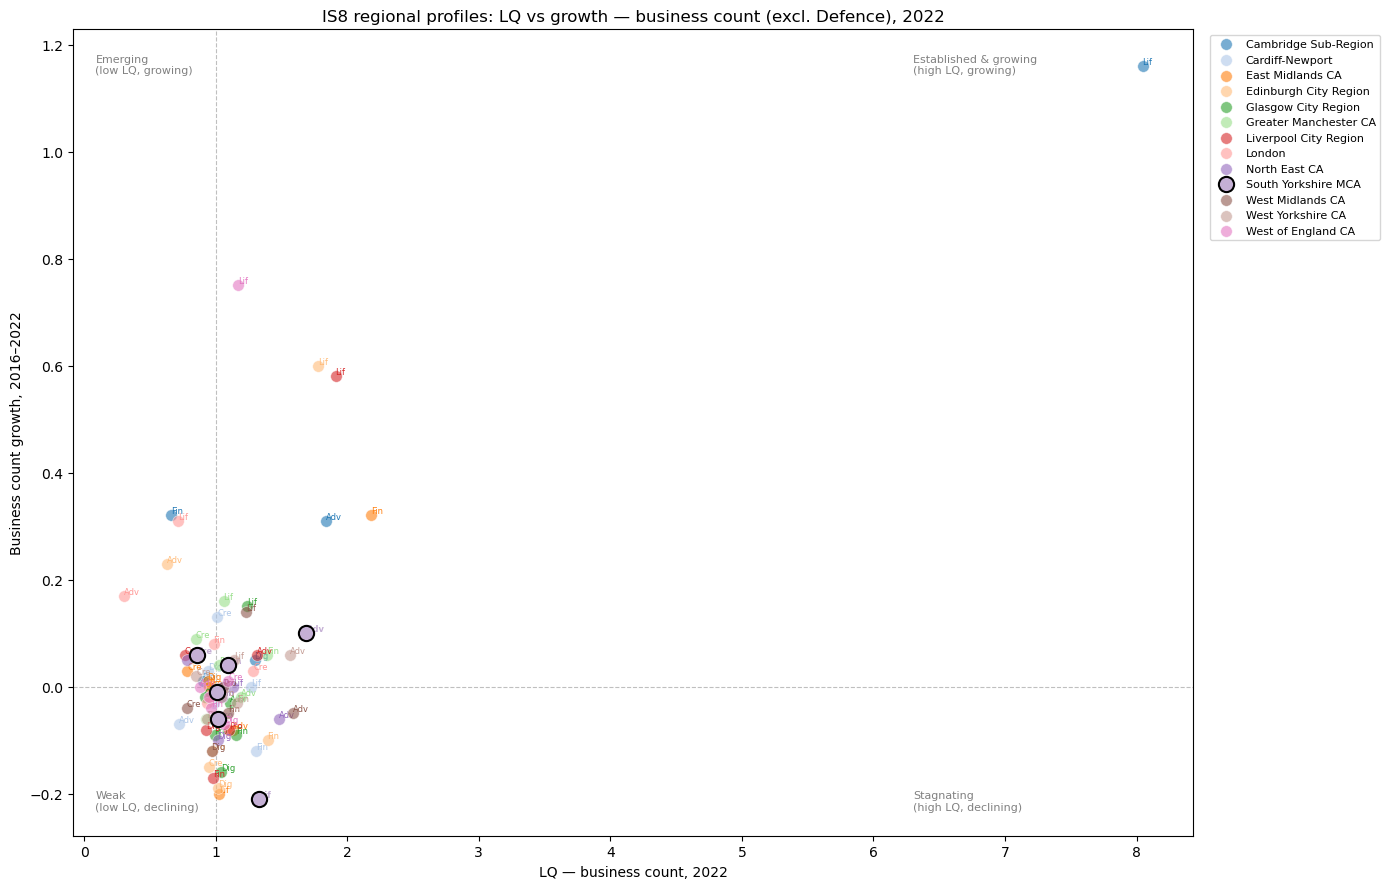

In [20]:
# --- 2D scatter: LQ vs growth by region and sector — business count (region-level aggregation) ---

# melt growth_bus_pivot back to long format
growth_bus_long = growth_bus_pivot.reset_index().melt(id_vars='region', var_name='IS8_SECTOR', value_name='growth_bus')

# merge with region-level LQ bus
scatter_bus_df = region_lq_bus[['region', 'IS8_SECTOR', 'lq_bus']].merge(growth_bus_long, on=['region', 'IS8_SECTOR'])

# exclude Defence
scatter_bus_df = scatter_bus_df[scatter_bus_df['IS8_SECTOR'] != 'Defence']

HIGHLIGHT = 'South Yorkshire MCA'
regions = sorted(scatter_bus_df['region'].unique())
colors = plt.cm.tab20.colors
region_colors = {r: colors[i] for i, r in enumerate(regions)}

fig, ax = plt.subplots(figsize=(14, 9))

for region in regions:
    data = scatter_bus_df[scatter_bus_df['region'] == region]
    is_highlight = region == HIGHLIGHT
    ax.scatter(data['lq_bus'], data['growth_bus'],
               color=region_colors[region], label=region,
               s=120 if is_highlight else 70,
               alpha=1.0 if is_highlight else 0.6,
               edgecolors='black' if is_highlight else 'white',
               linewidth=1.5 if is_highlight else 0.5,
               zorder=5 if is_highlight else 3)
    for _, row in data.iterrows():
        ax.annotate(row['IS8_SECTOR'][:3],
                    (row['lq_bus'], row['growth_bus']),
                    fontsize=6, ha='left', va='bottom',
                    color=region_colors[region],
                    fontweight='bold' if is_highlight else 'normal')

ax.axvline(x=1, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

ax.text(0.02, 0.97, 'Emerging\n(low LQ, growing)',               transform=ax.transAxes, fontsize=8, va='top',    color='gray')
ax.text(0.75, 0.97, 'Established & growing\n(high LQ, growing)', transform=ax.transAxes, fontsize=8, va='top',    color='gray')
ax.text(0.02, 0.03, 'Weak\n(low LQ, declining)',                 transform=ax.transAxes, fontsize=8, va='bottom', color='gray')
ax.text(0.75, 0.03, 'Stagnating\n(high LQ, declining)',          transform=ax.transAxes, fontsize=8, va='bottom', color='gray')

ax.set_xlabel(f'LQ — business count, {latest_year}', fontsize=10)
ax.set_ylabel(f'Business count growth, {start_year}–{end_year}', fontsize=10)
ax.set_title(f'IS8 regional profiles: LQ vs growth — business count (excl. Defence), {latest_year}', fontsize=12)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig(f'../../output/graphs/Franco/regional_scatter_lq_growth_bus_{latest_year}.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
# --- Interactive scatter: business count ---
from ipywidgets import SelectMultiple, Button, Output, VBox, HBox, Label
import matplotlib.patches as mpatches

all_regions_bus = sorted(scatter_bus_df['region'].unique())

region_selector_bus = SelectMultiple(
    options=all_regions_bus,
    value=all_regions_bus,
    description='Regions:',
    layout={'width': '280px', 'height': '260px'}
)

select_all_btn_bus   = Button(description='Select all',   layout={'width': '120px'})
deselect_all_btn_bus = Button(description='Deselect all', layout={'width': '120px'})
out_bus = Output()

def plot_scatter_bus(selected_regions):
    out_bus.clear_output(wait=True)
    with out_bus:
        data = scatter_bus_df[scatter_bus_df['region'].isin(selected_regions)]
        fig, ax = plt.subplots(figsize=(14, 9))

        for region in selected_regions:
            rd = data[data['region'] == region].reset_index(drop=True)
            is_highlight = region == HIGHLIGHT
            ax.scatter(rd['lq_bus'], rd['growth_bus'],
                       color=region_colors[region],
                       s=120 if is_highlight else 70,
                       alpha=1.0 if is_highlight else 0.6,
                       edgecolors='black' if is_highlight else 'white',
                       linewidth=1.5 if is_highlight else 0.5,
                       zorder=5 if is_highlight else 3)
            for _, row in rd.iterrows():
                ax.annotate(row['IS8_SECTOR'][:3],
                            (row['lq_bus'], row['growth_bus']),
                            fontsize=6, ha='left', va='bottom',
                            color=region_colors[region],
                            fontweight='bold' if is_highlight else 'normal')

        ax.axvline(x=1, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
        ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

        ax.text(0.02, 0.97, 'Emerging\n(low LQ, growing)',               transform=ax.transAxes, fontsize=8, va='top',    color='gray')
        ax.text(0.75, 0.97, 'Established & growing\n(high LQ, growing)', transform=ax.transAxes, fontsize=8, va='top',    color='gray')
        ax.text(0.02, 0.03, 'Weak\n(low LQ, declining)',                 transform=ax.transAxes, fontsize=8, va='bottom', color='gray')
        ax.text(0.75, 0.03, 'Stagnating\n(high LQ, declining)',          transform=ax.transAxes, fontsize=8, va='bottom', color='gray')

        legend_handles = [mpatches.Patch(color=region_colors[r], label=r) for r in selected_regions]
        ax.legend(handles=legend_handles, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
        ax.set_xlabel(f'LQ — business count, {latest_year}', fontsize=10)
        ax.set_ylabel(f'Business count growth, {start_year}–{end_year}', fontsize=10)
        ax.set_title(f'IS8 regional profiles: LQ vs growth — business count (excl. Defence), {latest_year}', fontsize=12)
        plt.tight_layout()
        plt.savefig(f'../../output/graphs/Franco/regional_scatter_lq_growth_bus_{latest_year}.png', dpi=150, bbox_inches='tight')
        plt.show()

def on_change_bus(change):
    if change['name'] == 'value':
        plot_scatter_bus(list(change['new']))

region_selector_bus.observe(on_change_bus, names='value')
select_all_btn_bus.on_click(lambda b: setattr(region_selector_bus, 'value', all_regions_bus))
deselect_all_btn_bus.on_click(lambda b: setattr(region_selector_bus, 'value', []))

plot_scatter_bus(all_regions_bus)

display(VBox([
    Label('Hold Ctrl/Cmd to select multiple regions:'),
    HBox([region_selector_bus, VBox([select_all_btn_bus, deselect_all_btn_bus])]),
    out_bus
]))